# Balance-Checked Randomization vs. Complete Randomization
Julian Hsu

29-Jul-2026

The purpose of this notebook is to compare the **bias** and **standard error** of the estimated treatment effect under two experiment designs:

1. **Complete randomization** (the standard): treatment is assigned once, at random.
2. **Balance-checked randomization**: treatment is assigned at random, but we then *check* that the treatment and control groups look similar on a covariate that determines the outcome. If they are too different, we re-draw the assignment until they are similar.

We look at balance-checking at two strictness levels -- requiring the treatment/control means of the covariate to be within **0.01 SD** and within **0.001 SD** of each other -- and compare both against doing no balance check at all.

**sound byte:**

Checking covariate balance and re-drawing your randomization until treatment and control look alike on an outcome-driving covariate is *not cheating* -- it stays unbiased, and it makes your estimate genuinely more precise. Even a loose check captures most of the gain: precision improves toward a floor set by the outcome's own irreducible noise, so tightening the threshold far past that point buys little. 

But there is a catch: the reported standard error from your experimentation software will be *too big* because it does not know you re-randomized. Its reported standard error assumes plain complete randomization, so it will *overstate* your uncertainty. To actually cash in the precision you bought at design time, you must control for that covariate when you analyze the experiment. 

**But** you'd realize that gain anyway if you control for the covariate with pure randomization! 

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

## Data Generating and Assignment Functions

There is one covariate `x` that *determines the outcome* through the coefficient `beta`. The true treatment effect is `tau`, which is constant across units. The outcome is
$$ y_i = \tau \, w_i + \beta \, x_i + \varepsilon_i .$$

The designs differ only in how the treatment indicator `w` is assigned:

- `assign_complete`: draw exactly half the units to treatment, once. This is the "no balance check" baseline.
- `assign_balanced`: keep re-drawing until the treatment/control **means of `x`** are within `threshold_sd` standard deviations of `x` of each other. This is the "verify similarity on the outcome-driving covariate" step; a smaller `threshold_sd` is a stricter check.

In [5]:
def assign_complete(n):
    """Standard complete randomization: exactly half treated, drawn once."""
    w = np.zeros(n)
    w[np.random.choice(n, n // 2, replace=False)] = 1
    return w


def assign_balanced(x, threshold_sd, max_tries=100000):
    """Rerandomization: keep re-drawing the assignment until the treatment and
    control means of the outcome-driving covariate x are within `threshold_sd`
    standard deviations of x of each other."""
    n = len(x)
    threshold_abs = threshold_sd * x.std()
    for attempt in range(1, max_tries + 1):
        w = np.zeros(n)
        w[np.random.choice(n, n // 2, replace=False)] = 1
        imbalance = x[w == 1].mean() - x[w == 0].mean()
        if abs(imbalance) < threshold_abs:
            return w, attempt
    return w, attempt


def dgp(n=1000, tau=1.0, beta=2.0, threshold_sd=None):
    """x determines the outcome (coefficient beta); tau is the true effect.
    threshold_sd=None gives no balance check (complete randomization)."""
    x = np.random.normal(0, 1, n)
    if threshold_sd is None:
        w, tries = assign_complete(n), 1
    else:
        w, tries = assign_balanced(x, threshold_sd)
    y = tau * w + beta * x + np.random.normal(0, 1, n)
    return pd.DataFrame({'y': y, 'w': w, 'x': x}), tries

## Estimating Functions

`estimate_naive` is the standard experiment readout: a difference in means (OLS of `y` on `w`) that **ignores `x`**. This is what a typical experimentation platform reports.

`estimate_adjusted` controls for `x`. We include it to show how to actually realize the precision gain from balance-checking.

In [6]:
def estimate_naive(df):
    """Difference-in-means via OLS, ignoring x -- the standard readout."""
    res = sm.OLS(df['y'], sm.add_constant(df['w'])).fit()
    return res.params['w'], res.bse['w']


def estimate_adjusted(df):
    """OLS controlling for the outcome-driving covariate x."""
    res = sm.OLS(df['y'], sm.add_constant(df[['w', 'x']])).fit()
    return res.params['w'], res.bse['w']

## Simulations

We sweep three scenarios: no balance check, a balance check at 0.01 SD, and a stricter one at 0.001 SD. For each scenario we run many experiments, recording the naive estimate and its reported standard error, the covariate-adjusted estimate, and how many re-draws the balance check took.

In [7]:
np.random.seed(42)
n_sims = 2000
tau_true = 1.0

# (label, threshold in SD of x); None means no balance check.
scenarios = [
    ('No balancing',        None),
    ('Balance < 0.01 SD',   0.01),
    ('Balance < 0.001 SD',  0.001),
]

records = []
for label, threshold_sd in scenarios:
    for _ in range(n_sims):
        df, tries = dgp(n=1000, tau=tau_true, beta=2.0, threshold_sd=threshold_sd)
        est_n, se_n = estimate_naive(df)
        est_a, se_a = estimate_adjusted(df)
        records.append({'scenario': label, 'tries': tries,
                        'est_naive': est_n, 'se_naive': se_n,
                        'est_adj': est_a, 'se_adj': se_a})

sim = pd.DataFrame(records)
order = [s[0] for s in scenarios]
print('Median re-draws needed per scenario:')
print(sim.groupby('scenario')['tries'].median().reindex(order).astype(int))

Median re-draws needed per scenario:
scenario
No balancing           1
Balance < 0.01 SD      6
Balance < 0.001 SD    50
Name: tries, dtype: int32


## Bias and Standard Error

For each scenario we compute, for the **naive** (difference-in-means) estimator:

- `bias` = mean estimate minus the true effect `tau`.
- `empirical_se` = the standard deviation of the estimates across simulations. **This is the true standard error** -- how much the estimate actually bounces around.
- `reported_se` = the average standard error the software prints. This is what you would report from a single experiment.

We also show the empirical SE of the **covariate-adjusted** estimator.

In [8]:
def summarize(g):
    return pd.Series({
        'bias_naive':         g['est_naive'].mean() - tau_true,
        'empirical_se_naive': g['est_naive'].std(),
        'reported_se_naive':  g['se_naive'].mean(),
        'bias_adj':           g['est_adj'].mean() - tau_true,
        'empirical_se_adj':   g['est_adj'].std(),
    })

summary = sim.groupby('scenario').apply(summarize, include_groups=False).reindex(order)
summary.round(4)

,bias_naive,empirical_se_naive,reported_se_naive,bias_adj,empirical_se_adj
scenario,,,,,
No balancing,0.0021,0.1423,0.1414,0.0003,0.0624
Balance < 0.01 SD,-0.0002,0.0643,0.1415,-0.0005,0.0636
Balance < 0.001 SD,0.0010,0.0635,0.1414,0.0011,0.0635


### Reading the table

- **Every scenario is unbiased.** `bias_naive` is ~0 whether or not we balance, and however strict the check. Re-drawing until the covariate is balanced does not tilt the estimate.
- **Balance-checking shrinks the true standard error -- but with diminishing returns.** `empirical_se_naive` drops sharply from "no balancing" balance check. This is because covariate imbalance -- a real source of noise -- is designed away. Notice that floor is essentially `empirical_se_adj`.
- **But the reported SE does not move.** `reported_se_naive` is essentially the same across all three scenarios, because the software assumes complete randomization and still sees `x` as unexplained residual noise. Under balancing the reported SE is *far larger* than the empirical SE: it is **conservative**. You are more precise than your readout admits.
- **Either control for X at the beginning or the end** -- adjustment at analysis time recovers essentially the same precision that balancing buys at design time.

## Distribution of the estimates

For each scenario we plot the **actual** distribution of the naive estimates (the histogram) against the **bell curve your software implies** -- a normal centered at the true effect with width equal to the *reported* SE.

Moving from no balancing to a 0.01 SD check sharply concentrates the histogram around the truth; tightening further to 0.001 SD looks nearly identical, because we have hit the noise floor. In every balanced case the implied curve barely changes: the reported SE keeps describing uncertainty you no longer have.

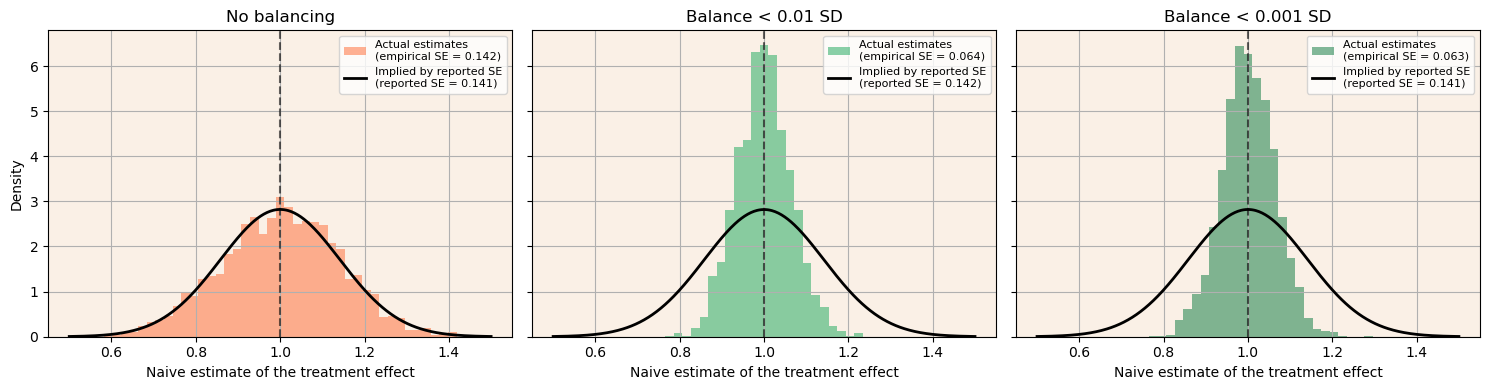

In [9]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(15, 4), sharex=True, sharey=True)
bins = np.linspace(0.5, 1.5, 50)
grid = np.linspace(0.5, 1.5, 400)
colors = ['coral', 'mediumseagreen', 'seagreen']

for ax, label, color in zip(axes, order, colors):
    est = sim.loc[sim.scenario == label, 'est_naive']
    rep_se = summary.loc[label, 'reported_se_naive']
    emp_se = summary.loc[label, 'empirical_se_naive']

    ax.hist(est, bins=bins, density=True, alpha=0.6, color=color,
            label=f'Actual estimates\n(empirical SE = {emp_se:.3f})')
    ax.plot(grid, stats.norm.pdf(grid, tau_true, rep_se), color='black', lw=2,
            label=f'Implied by reported SE\n(reported SE = {rep_se:.3f})')
    ax.axvline(tau_true, color='black', linestyle='--', alpha=0.6)
    ax.set_title(label)
    ax.set_xlabel('Naive estimate of the treatment effect')
    ax.legend(fontsize=8)
    ax.grid()
    ax.set_facecolor('linen')

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()